# DML Lab Assignment No. 4
## Building a Convolutional Neural Network (CNN) for Image Classification
**Dataset:** CIFAR-10

### Step 1: Import Required Libraries and Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)

# Class names for CIFAR-10
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(f'Training samples: {X_train.shape}, Test samples: {X_test.shape}')

TensorFlow version: 2.21.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training samples: (50000, 32, 32, 3), Test samples: (10000, 32, 32, 3)


### Step 2: Normalize Dataset (Reshape Training and Testing Images)

X_train shape: (50000, 32, 32, 3)
y_train_cat shape: (50000, 10)


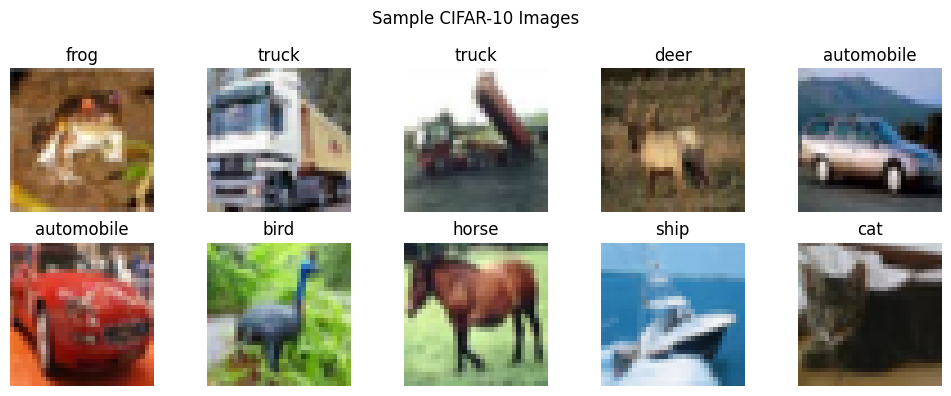

In [2]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print('X_train shape:', X_train.shape)
print('y_train_cat shape:', y_train_cat.shape)

# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images')
plt.tight_layout()
plt.show()

### Step 3: Build the CNN Model
- 3 Convolution layers with ReLU activation
- MaxPooling after each conv block
- Fully connected Dense layers
- Softmax output for 10 classes

In [3]:
model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # 10 classes
])

model.summary()

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Compile the Model
- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled successfully!')

Model compiled successfully!


### Step 5: Train the Model

In [5]:
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 137ms/step - accuracy: 0.4316 - loss: 1.5483 - val_accuracy: 0.5948 - val_loss: 1.1481
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 104s 147ms/step - accuracy: 0.6009 - loss: 1.1198 - val_accuracy: 0.6578 - val_loss: 0.9886
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 137ms/step - accuracy: 0.6631 - loss: 0.9548 - val_accuracy: 0.7026 - val_loss: 0.8476
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7000 - loss: 0.8501 - val_accuracy: 0.7350 - val_loss: 0.7833
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 140ms/step - accuracy: 0.7267 - loss: 0.7719 - val_accuracy: 0.7540 - val_loss: 0.7239
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7499 - loss: 0.7083 - val_accuracy: 0.7502 - val_loss: 0.7232
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.7666 - loss: 0.6658 - val_accuracy: 0.7726 - val_loss: 0.6725
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7803 - loss: 

### Step 6: Predict / Test the Model

Test Accuracy: 78.65%
Test Loss:     0.6910
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step


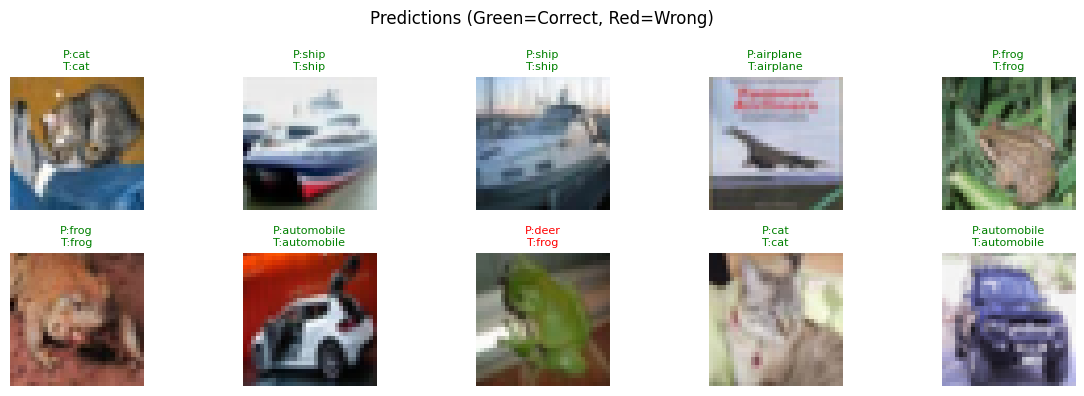

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss:     {test_loss:.4f}')

# Predictions on a few test images
predictions = model.predict(X_test[:10])
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i][0]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'P:{pred_label}\nT:{true_label}', color=color, fontsize=8)
    plt.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

### Step 7: Model Performance Visualization (Accuracy & Loss)

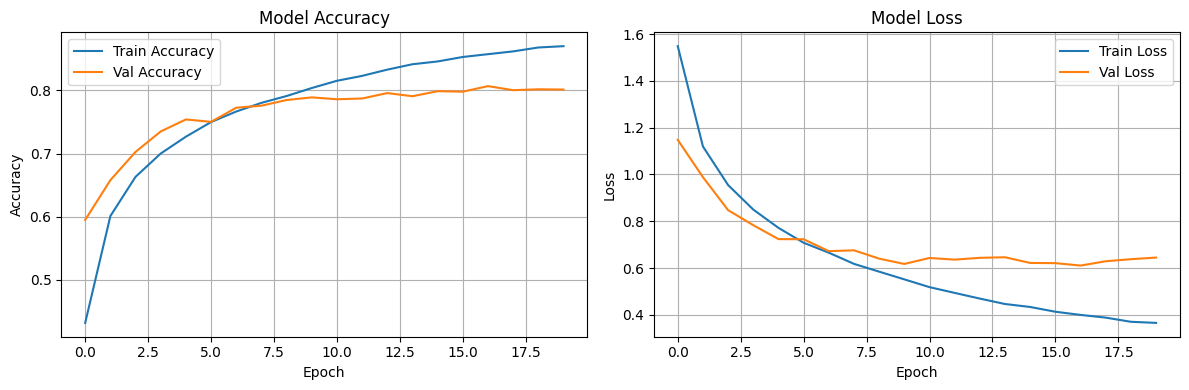

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()